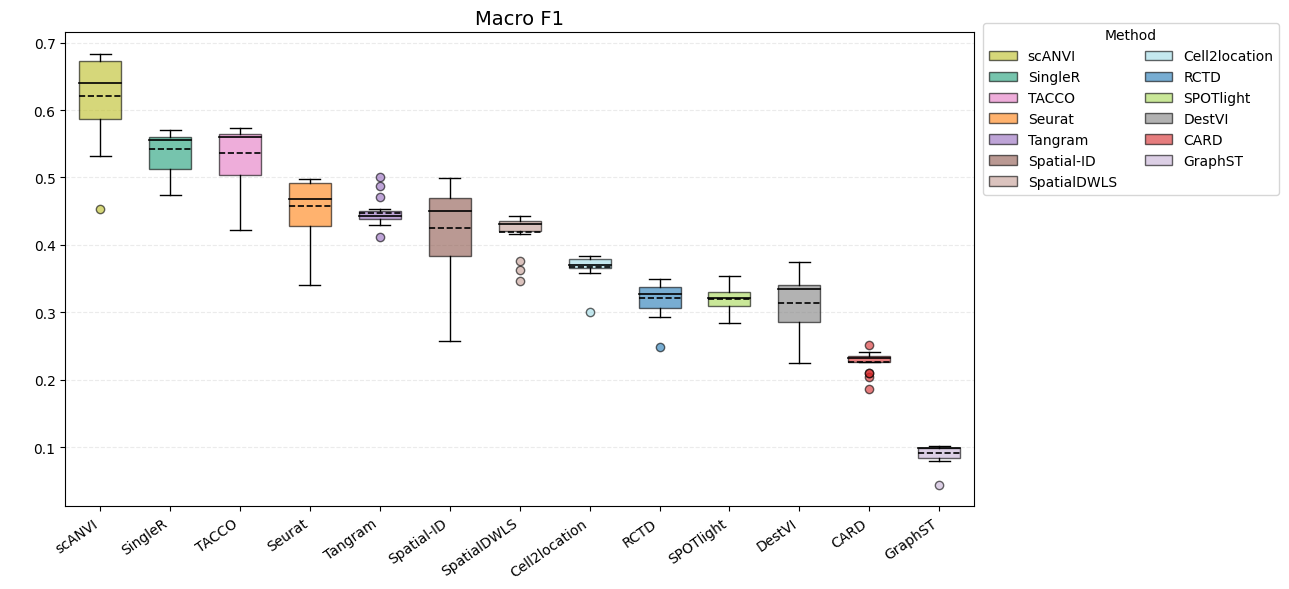

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Macro F1_boxplot_across_methods_sorted.pdf
[RANK] Macro F1 (mean, high→low):
       method  Macro F1_mean
       scANVI       0.621526
      SingleR       0.542255
        TACCO       0.536736
       Seurat       0.457097
      Tangram       0.447593
   Spatial-ID       0.425544
  SpatialDWLS       0.419009
Cell2location       0.367924
         RCTD       0.320960
    SPOTlight       0.319634
       DestVI       0.314268
         CARD       0.226762
      GraphST       0.091009
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Macro F1_ranking.csv


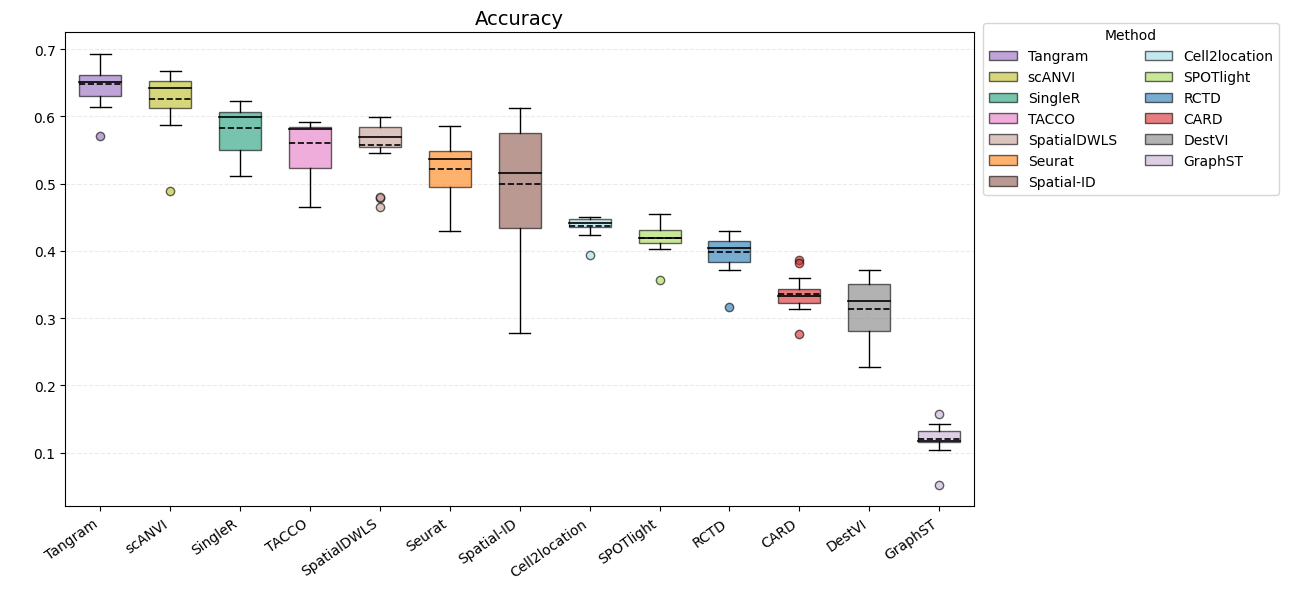

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Accuracy_boxplot_across_methods_sorted.pdf
[RANK] Accuracy (mean, high→low):
       method  Accuracy_mean
      Tangram       0.648530
       scANVI       0.625996
      SingleR       0.583044
        TACCO       0.560878
  SpatialDWLS       0.557335
       Seurat       0.522343
   Spatial-ID       0.499853
Cell2location       0.437765
    SPOTlight       0.419059
         RCTD       0.399089
         CARD       0.335640
       DestVI       0.313912
      GraphST       0.120372
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Accuracy_ranking.csv


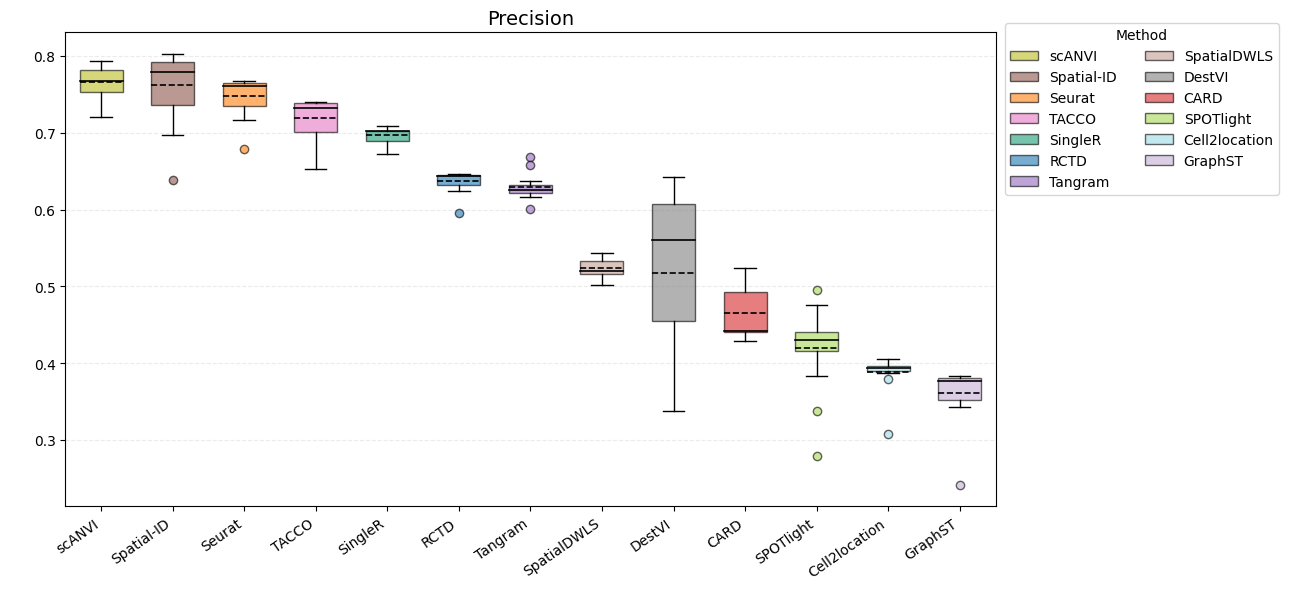

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Precision_boxplot_across_methods_sorted.pdf
[RANK] Precision (mean, high→low):
       method  Precision_mean
       scANVI        0.766247
   Spatial-ID        0.761507
       Seurat        0.747741
        TACCO        0.719728
      SingleR        0.696750
         RCTD        0.637311
      Tangram        0.629230
  SpatialDWLS        0.523451
       DestVI        0.517642
         CARD        0.464601
    SPOTlight        0.419579
Cell2location        0.388189
      GraphST        0.361423
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Precision_ranking.csv


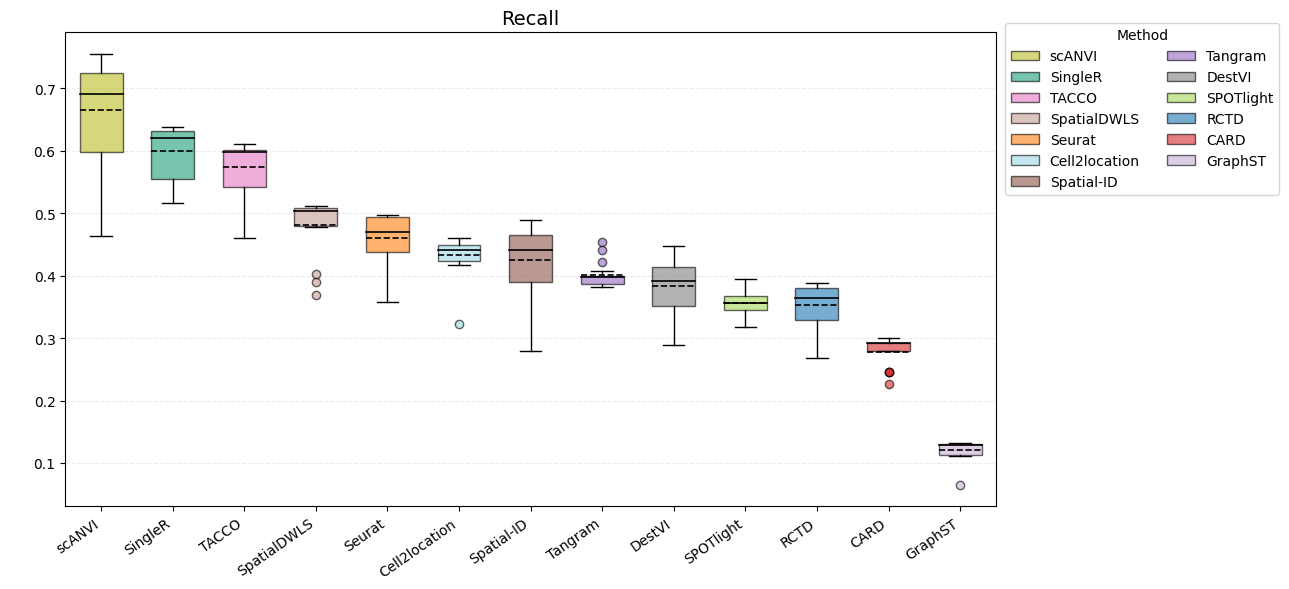

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Recall_boxplot_across_methods_sorted.pdf
[RANK] Recall (mean, high→low):
       method  Recall_mean
       scANVI     0.664571
      SingleR     0.600270
        TACCO     0.573712
  SpatialDWLS     0.480550
       Seurat     0.460833
Cell2location     0.432443
   Spatial-ID     0.425208
      Tangram     0.401033
       DestVI     0.382841
    SPOTlight     0.355609
         RCTD     0.353427
         CARD     0.278476
      GraphST     0.120296
Saved ranking: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Recall_ranking.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Patch
METHODS = [
    ("CARD",           "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/0503_F4_C_metric/metrics_results.csv",          "#d62728"),
    ("Cell2location",  "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/0503_F4_C_metric/metrics_results.csv", "#9edae5"),
    ("DestVI",         "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/0503_F4_C_metric/metrics_results.csv",        "#7f7f7f"),
    ("GraphST",        "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/0503_F4_C_metric/metrics_results.csv",       "#c5b0d5"),
    ("RCTD",           "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/0503_F4_C_metric/metrics_results.csv",          "#1f77b4"),
    ("scANVI",           "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/0503_F4_C_metric/metrics_results.csv",          "#bcbd22"),
    ("Seurat",         "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/0503_F4_C_metric/metrics_results.csv",        "#ff7f0e"),
    ("SingleR",        "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/0503_F4_C_metric/metrics_results.csv",       "#1b9e77"),
    ("SpatialDWLS",    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/0503_F4_C_metric/metrics_results.csv",   "#c49c94"),
    ("Spatial-ID",      "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/0503_F4_C_metric/metrics_results.csv",     "#8c564b"),
    ("SPOTlight",      "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/0503_F4_C_metric/metrics_results.csv",     "#A6D854"),
    ("TACCO",          "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/0503_F4_C_metric/metrics_results.csv",         "#e377c2"),
    ("Tangram",        "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/0503_F4_C_metric/metrics_results.csv",       "#9467bd"),
]
COLS = ["f1_macro", "accuracy", "precision", "recall"]
PLOT_ORDER = [("Macro F1", 0), ("Accuracy", 2), ("Precision", 1), ("Recall", 3)]  

def load_four_cols(p):
    df = pd.read_csv(p)
    df = df[COLS].apply(pd.to_numeric, errors="coerce")
    return [df[c].dropna().values for c in COLS]

# ===== read all methods data =====
loaded = []   # [(label, color, [ARI, ASW, NMI, avgbio]), ...]
skipped = []  # [(label, path)]
for label, path, color in METHODS:
    if not os.path.exists(path):
        skipped.append((label, path))
        continue
    try:
        vals = load_four_cols(path)
        loaded.append((label, color, vals))
    except Exception as e:
        print(f"[WARN] FAILED: {label} @ {path} | REASON: {e}")
        skipped.append((label, path))

if len(loaded) == 0:
    raise RuntimeError("NO SUCCESSFUL CSV")

first_ok_path = '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric'
 
out_dir = os.path.dirname(first_ok_path) if first_ok_path else "."
os.makedirs(out_dir, exist_ok=True)

def color_single_boxes(bp, colors_per_box):
    # set colors for each box
    for box, fc in zip(bp['boxes'], colors_per_box):
        box.set(facecolor=fc, edgecolor='black', alpha=0.6)
    for median in bp['medians']:
        median.set(color='black', linewidth=1.2)
    if 'means' in bp:
        for mean in bp['means']:
            mean.set(color='black', linewidth=1.2, linestyle='--')
    for whisker in bp['whiskers']:
        whisker.set(color='black')
    for cap in bp['caps']:
        cap.set(color='black')
    for flier, fc in zip(bp['fliers'], colors_per_box[:len(bp['fliers'])]):
        flier.set(marker='o', markerfacecolor=fc, markeredgecolor='black', alpha=0.6)

def plot_one_metric(metric_name, metric_idx):
    rows = []   # list of (label, color, arr, mean)

    for label, color, vals in loaded:
        arr = vals[metric_idx]
        if arr is None or len(arr) == 0:
            continue
        m = float(np.nanmean(arr))
        rows.append((label, color, arr, m))

    if not rows:
        print(f"[INFO] {metric_name} NO DATA")
        return
    rows.sort(key=lambda t: t[3], reverse=True)

    method_labels = [r[0] for r in rows]
    method_colors = [r[1] for r in rows]
    data_arrays   = [r[2] for r in rows]
    means_sorted  = [r[3] for r in rows]
    x_positions = np.arange(1, len(data_arrays) + 1)
    plt.figure(figsize=(max(12, 1.0 * len(data_arrays)), 6))
    bp = plt.boxplot(
        data_arrays,
        positions=x_positions,
        widths=0.6,
        showmeans=True,
        meanline=True,
        whis=1.5,
        patch_artist=True
    )
    color_single_boxes(bp, method_colors)
    plt.xticks(x_positions, method_labels, rotation=35, ha='right', fontsize=10)
    plt.ylabel(' ', fontsize=12)
    plt.title(metric_name, fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.25)
    legend_handles = [Patch(facecolor=fc, edgecolor='black', alpha=0.6, label=lb)
                      for lb, fc in zip(method_labels, method_colors)]
    plt.legend(
        handles=legend_handles,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.02),
        borderaxespad=0.,
        ncol=2 if len(legend_handles) > 8 else 1
    )

    plt.tight_layout()
    out_png = os.path.join(out_dir, f"{metric_name}_boxplot_across_methods_sorted.pdf")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_png}")
    rank_df = pd.DataFrame({
        "method": method_labels,
        f"{metric_name}_mean": means_sorted
    })
    out_csv = os.path.join(out_dir, f"{metric_name}_ranking.csv")
    rank_df.to_csv(out_csv, index=False)
    print(f"[RANK] {metric_name} (mean, high→low):")
    print(rank_df.to_string(index=False))
    print(f"Saved ranking: {out_csv}")
for metric_name, idx in PLOT_ORDER:
    plot_one_metric(metric_name, idx)

if skipped:
    print("\n[INFO] SKIPPED:")
    for label, path in skipped:
        print(f"  - {label}: {path}")


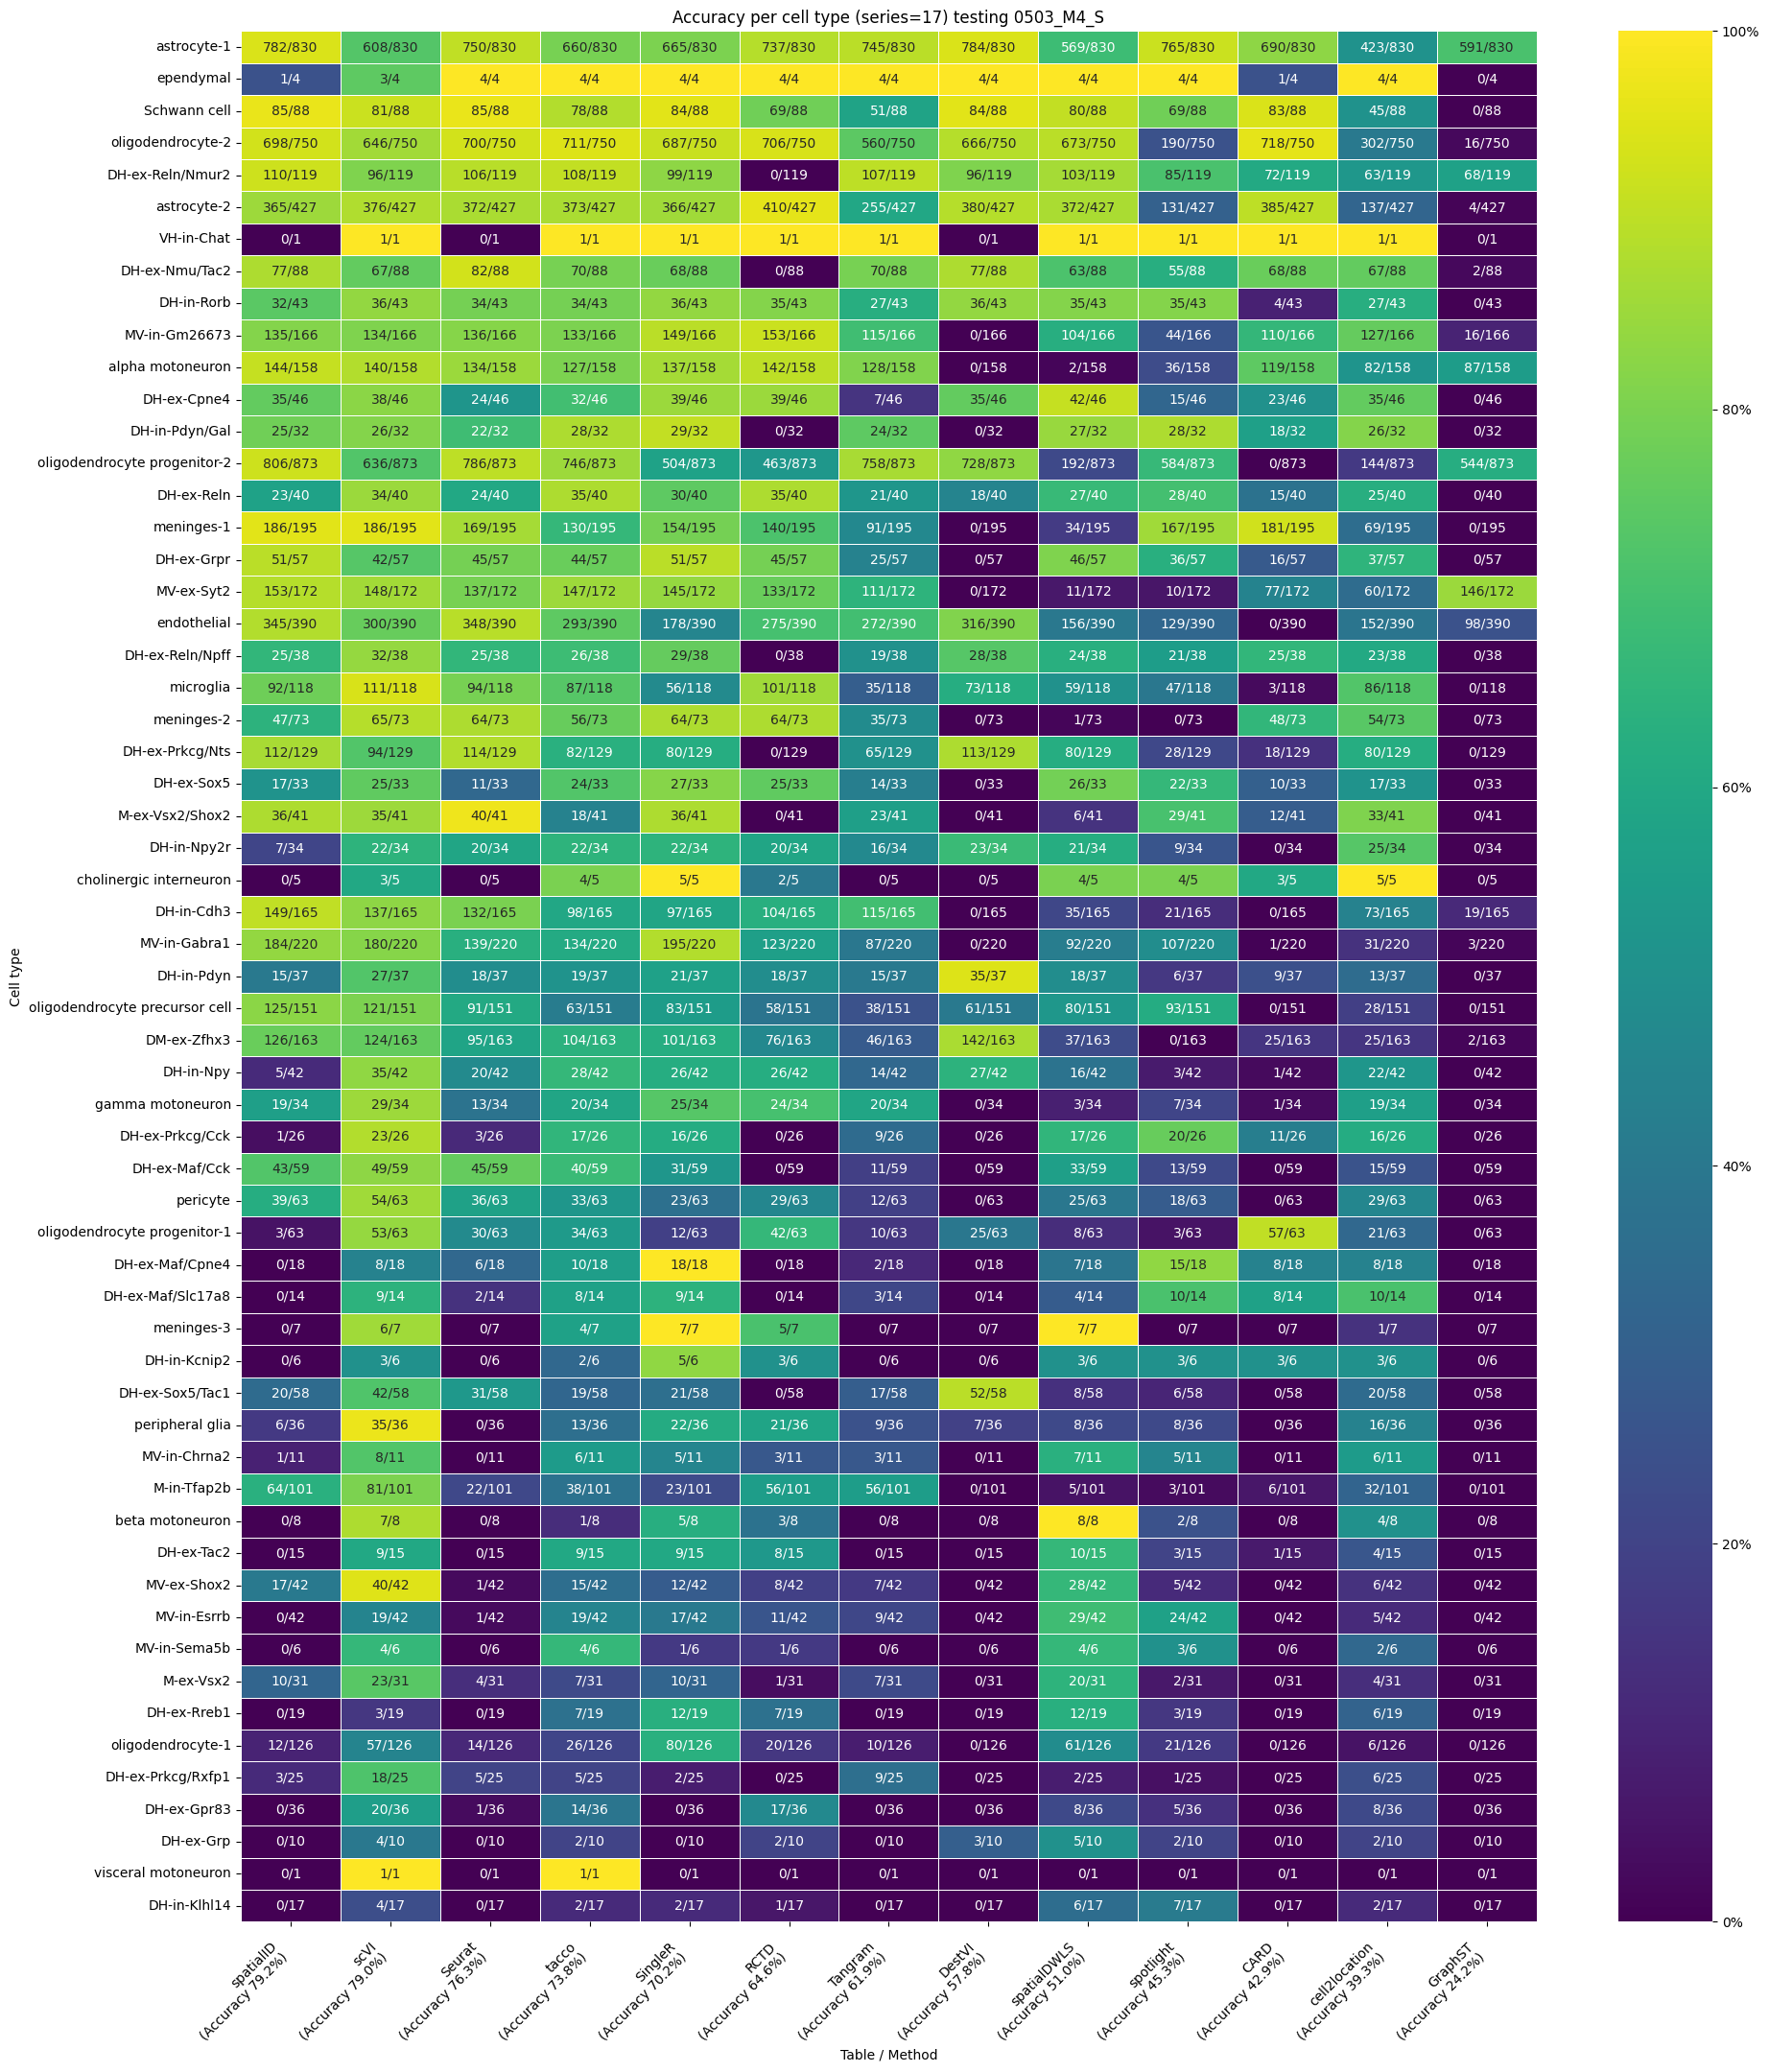

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os
from matplotlib.ticker import PercentFormatter

base = "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer"
paths = glob(os.path.join(base, "*/0503_F4_C_metric/per_celltype_accuracy_by_series.csv"))
# USE series=17 which has the largest reference volume 
series_to_use = 17   
acc_dfs = []      
ann_dfs = []

for p in paths:
    method = p.split("/label_transfer/")[1].split("/")[0]
    d = pd.read_csv(p)
    '''
    if 'cell2location' in method:
        series_to_use = 1
    else:
        series_to_use = 17
    '''
    if "series" in d.columns:
        d["series"] = pd.to_numeric(d["series"], errors="coerce")
        d = d[d["series"] == series_to_use]
    n_true_col = None
    for cand in ["n_true", "n_total", "total", "n", "n_samples", "n_obs"]:
        if cand in d.columns:
            n_true_col = cand
            break
    if n_true_col is None and "n_incorrect" in d.columns and "n_correct" in d.columns:
        d["__n_true__"] = d["n_correct"] + d["n_incorrect"]
        n_true_col = "__n_true__"
    if n_true_col is None or "n_correct" not in d.columns:
        print(f"[WARN] {method}: lack of n_true/n_correct, skip {p}")
        continue
    d = d[["cell_type", "n_correct", n_true_col]].copy()
    d = d.groupby("cell_type", as_index=False).sum()
    denom = d[n_true_col].replace(0, np.nan)
    acc_df = d[["cell_type"]].copy()
    acc_df[method] = (d["n_correct"] / denom).clip(0, 1)
    acc_dfs.append(acc_df)
    ncor = d["n_correct"].fillna(0).astype("Int64")
    ntot = d[n_true_col].fillna(0).astype("Int64")
    ann_df = d[["cell_type"]].copy()
    ann_df[method] = ncor.astype(str) + "/" + ntot.astype(str)
    ann_dfs.append(ann_df)
mat = None
for df in acc_dfs:
    mat = df if mat is None else mat.merge(df, on="cell_type", how="outer")

ann = None
for df in ann_dfs:
    ann = df if ann is None else ann.merge(df, on="cell_type", how="outer")

if mat is None or mat.empty:
    raise RuntimeError("no data")

mat = mat.set_index("cell_type").astype(float)
mat = mat.fillna(0.0)

ann = ann.set_index("cell_type")

ann = ann.reindex(index=mat.index, columns=mat.columns).fillna("0/0")
ann = ann.reindex(index=mat.index, columns=mat.columns)
row_order = mat.mean(axis=1).sort_values(ascending=False).index
mat = mat.loc[row_order]
ann = ann.loc[row_order]

col_order = mat.mean(axis=0).sort_values(ascending=False).index
mat = mat[col_order]
ann = ann[col_order]
def split_frac(s):
    if isinstance(s, str) and "/" in s:
        a, b = s.split("/")
        try:
            return int(a), int(b)
        except:
            return 0, 0
    return 0, 0
nc_mat = ann.applymap(lambda x: split_frac(x)[0]).astype(int)  # TP
nt_mat = ann.applymap(lambda x: split_frac(x)[1]).astype(int)  
col_nc = nc_mat.sum(axis=0)
col_nt = nt_mat.sum(axis=0).replace(0, np.nan)
col_micro = (col_nc / col_nt).fillna(0.0)

col_order = col_micro.sort_values(ascending=False).index
mat = mat[col_order]
ann = ann[col_order]
col_micro = col_micro[col_order]
plt.figure(figsize=(1.2*mat.shape[1] + 4, 0.3*mat.shape[0] + 4))
ax = sns.heatmap(
    mat, vmin=0, vmax=1, cmap="viridis",
    annot=ann.values, fmt="",
    linewidths=0.5, linecolor="white",
    cbar_kws={"format": PercentFormatter(xmax=1)}
)
import re
def split_frac(s):
    if isinstance(s, str) and "/" in s:
        a,b = s.split("/")
        try:
            return int(a), int(b)
        except:
            return 0, 0
    return 0, 0
nc_mat = ann.applymap(lambda x: split_frac(x)[0]).astype(int)
nt_mat = ann.applymap(lambda x: split_frac(x)[1]).astype(int)

col_nc = nc_mat.sum(axis=0)      
col_nt = nt_mat.sum(axis=0)      
col_micro = (col_nc / col_nt.replace(0, np.nan)).fillna(0.0)
row_nc = nc_mat.sum(axis=1)
row_nt = nt_mat.sum(axis=1)
row_micro = (row_nc / row_nt.replace(0, np.nan)).fillna(0.0)
xticks = [f"{name}\n(Accuracy {col_micro[name]:.1%})" for name in mat.columns]
yticks = [f"{name}  (Accuracy {row_micro[name]:.1%})" for name in mat.index]

ax.set_xticklabels(xticks, rotation=45, ha="right")
#ax.set_yticklabels(yticks, rotation=0, va="center")
ax.tick_params(axis='x', which='major', pad=10)

ax.set_xlabel("Table / Method")
ax.set_ylabel("Cell type")
ax.set_title(f"Accuracy per cell type (series={series_to_use}) testing 0503_M4_S")
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.tight_layout()
os.makedirs(os.path.join(base, "metric"), exist_ok=True)
plt.savefig(os.path.join(base, "metric", f"1022_accuracy_heatmap_series{series_to_use}_fraction.png"), dpi=300)
plt.show()
mat.to_csv(os.path.join(base, "metric", f"1022_accuracy_matrix_series{series_to_use}.csv"))
ann.to_csv(os.path.join(base, "metric", f"1022_accuracy_matrix_series{series_to_use}_fraction.csv"))
